In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from nltk.probability import FreqDist
import pymorphy3

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [9]:
with open('2020.txt', 'r') as file:
    data = file.read()

In [11]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [13]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [15]:
tokenized = tokenize_text(data)

In [17]:
all_words = FreqDist(tokenized)

In [19]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('брикс', 297), ('страна', 209), ('режим', 115), ('видеоконференция', 110), ('сотрудничество', 79), ('международный', 75), ('встреча', 62), ('заседание', 62), ('отмечать', 54), ('группа', 54), ('приветствовать', 53), ('вопрос', 52), ('развитие', 51), ('также', 51), ('область', 51), ('рамка', 50), ('цель', 48), ('оон', 46), ('министр', 43), ('год', 42), ('безопасность', 42), ('октябрь', 41), ('рабочий', 38), ('сфера', 37), ('ноябрь', 35), ('обеспечение', 35), ('усилие', 34), ('важность', 34), ('форум', 34), ('связь', 33), ('подчёркивать', 32), ('укрепление', 30), ('проведение', 29), ('государство', 28), ('сентябрь', 28), ('борьба', 28), ('призывать', 27), ('мера', 27), ('наш', 26), ('заявлять', 26), ('число', 26), ('создание', 25), ('июль', 25), ('который', 24), ('включая', 24), ('совместный', 24), ('инициатива', 24), ('роль', 23), ('признать', 23), ('совет', 23), ('экономический', 23), ('использование', 23), ('экономика', 22), ('итог', 22), ('организация',

C:\Temp\ipykernel_10648\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


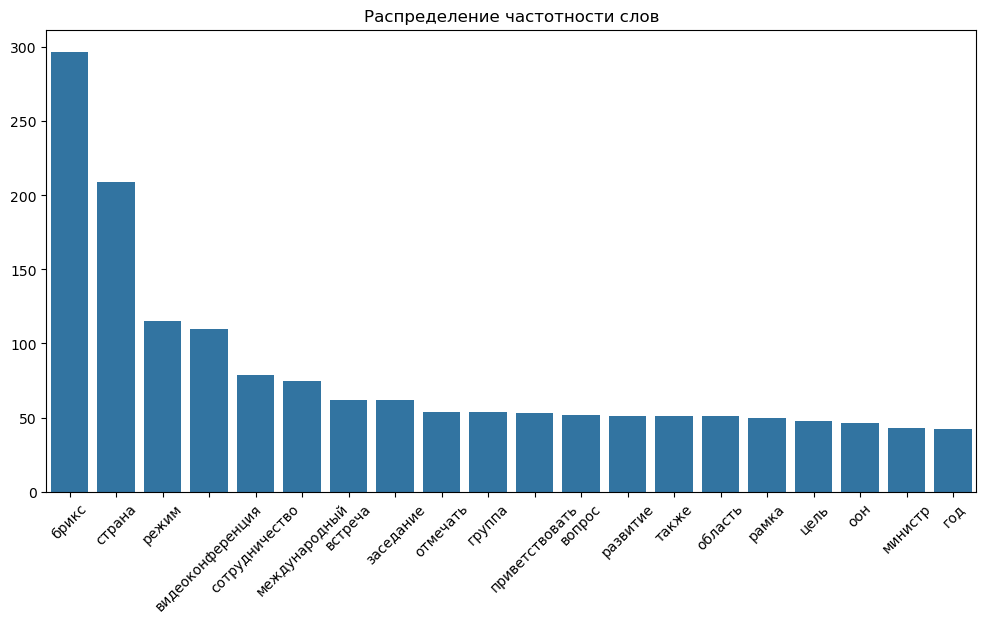

In [21]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [22]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [25]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_10648\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


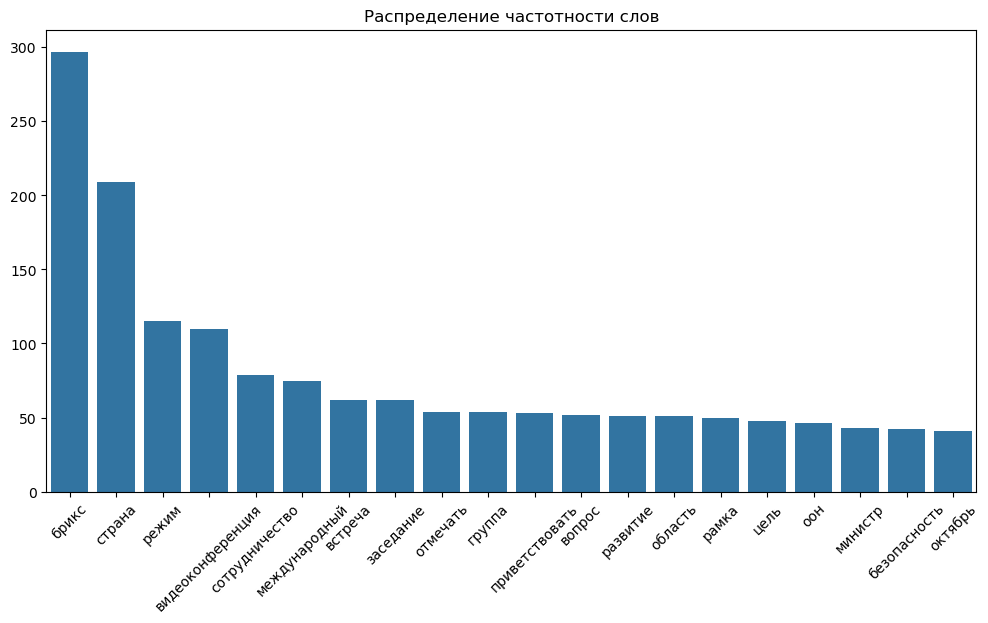

In [27]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [29]:
textt = ','.join(w for w in tokens)

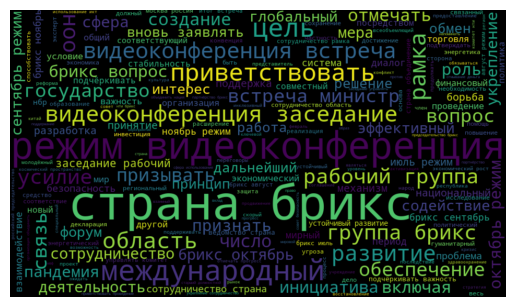

In [31]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [33]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [36]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [37]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['сфера', 'министр', 'цель', 'развитие', 'вопрос', 'отмечать', 'заседание', 'международный', 'видеоконференция', 'режим']


Top 10 words for topic #1:
['безопасность', 'оон', 'рамка', 'область', 'приветствовать', 'группа', 'встреча', 'сотрудничество', 'страна', 'брикс']




In [38]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['обеспечение', 'ноябрь', 'сфера', 'цель', 'развитие', 'вопрос', 'отмечать', 'заседание', 'видеоконференция', 'режим']


Top 10 words for topic #1:
['октябрь', 'безопасность', 'оон', 'рамка', 'область', 'приветствовать', 'группа', 'встреча', 'сотрудничество', 'страна']


Top 10 words for topic #2:
['создание', 'призывать', 'проведение', 'укрепление', 'важность', 'усилие', 'рабочий', 'министр', 'международный', 'брикс']




Вывод: тематика декларации 2020 г. посвящена общим вопросам международного сотрудничества и, конечно, пандемии КОВИД19